# **Multidisciplinary Dataset Analysis**

In [1]:
# Cell 1: Import Libraries
import os
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from transformers import GPT2Tokenizer
import json
from pathlib import Path
import re
from tqdm import tqdm
import spacy
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')

# Base path for the dataset
BASE_PATH = "/Users/farooqkhan/My Mac/GitHub/LLMs/polymath-1/splits"
if not os.path.exists(BASE_PATH):
    raise FileNotFoundError(f"Base path {BASE_PATH} does not exist.")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/farooqkhan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/farooqkhan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
# Cell 2: Load Data
def load_dataset():
    splits = ['train', 'val']
    data = []
    for split in splits:
        try:
            with open(Path(BASE_PATH) / f"{split}_split.json", "r") as f:
                split_data = json.load(f)
                for item in split_data:
                    item['split'] = split
                data.extend(split_data)
        except FileNotFoundError:
            print(f"File {split}_split.json not found in {BASE_PATH}.")
            continue
    return pd.DataFrame(data)

In [3]:
# Cell 3: Basic Statistics
def compute_basic_stats(df):
    stats = {
        'Total Samples': len(df),
        'Average Length': df['text'].str.len().mean(),
        'Median Length': df['text'].str.len().median(),
        'Min Length': df['text'].str.len().min(),
        'Max Length': df['text'].str.len().max(),
        'Samples per Split': df['split'].value_counts().to_dict()
    }
    return pd.DataFrame.from_dict(stats, orient='index', columns=['Value'])

In [4]:
# Cell 4: Domain Analysis
def analyze_domains(df):
    # Predefined keywords for each domain
    domain_keywords = {
        'biology': ['gene', 'protein', 'cell', 'dna', 'rna', 'enzyme'],
        'chemistry': ['molecule', 'reaction', 'bond', 'electron', 'atom'],
        'physics': ['quantum', 'force', 'energy', 'particle', 'field']
    }

    # Ensure keywords are lowercase
    domain_keywords = {k: [kw.lower() for kw in v] for k, v in domain_keywords.items()}

    domain_counts = {domain: [] for domain in domain_keywords}

    for text in df['text']:
        text = text.lower()
        for domain, keywords in domain_keywords.items():
            count = sum(1 for keyword in keywords if keyword in text)
            domain_counts[domain].append(count)

    for domain in domain_counts:
        df[f'{domain}_keywords'] = domain_counts[domain]

    return df

In [5]:
# Cell 5: Visualization
def plot_domain_distribution(df, colors=None, font_size=12):
    """
    Visualize domain distribution with customizable colors and font size.

    Parameters:
        df (DataFrame): The dataset with domain keyword counts.
        colors (list of str): Hex values for bar/pie chart colors (default colors used if None).
        font_size (int): Font size for chart text.
    """
    # Default hex colors if not provided
    if colors is None:
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

    domain_cols = ['biology_keywords', 'chemistry_keywords', 'physics_keywords']
    domain_presence = (df[domain_cols] > 0).sum()

    # Bar chart for domain distribution
    plt.figure(figsize=(12, 6))
    sns.barplot(x=domain_presence.index, y=domain_presence.values, hue=domain_presence.index, 
                palette=colors, dodge=False, legend=False)
    plt.title('Domain Distribution in Dataset', fontsize=font_size)
    plt.ylabel('Number of Samples', fontsize=font_size)
    plt.xticks(rotation=45, fontsize=font_size)
    plt.tight_layout()
    plt.show()

    # Pie chart for domain overlap
    plt.figure(figsize=(8, 8))
    domain_overlap = (df[domain_cols] > 0).sum(axis=1).value_counts()
    plt.pie(domain_overlap, labels=[f'{i} domains' for i in domain_overlap.index], 
            autopct='%1.1f%%', colors=colors)
    plt.title('Domain Overlap in Samples', fontsize=font_size)
    plt.show()

In [6]:
# Cell 6: Token Analysis
def analyze_tokens(df, colors=None, font_size=12):
    """
    Analyze token length distribution and vocabulary usage.

    Parameters:
        df (DataFrame): The dataset to analyze.
        colors (list of str): Hex value for histogram color (default is '#1f77b4').
        font_size (int): Font size for chart text.
    """
    tokenizer = GPT2Tokenizer.from_pretrained('distilgpt2')

    token_lengths = []
    vocab_usage = Counter()

    for text in tqdm(df['text']):
        tokens = tokenizer.encode(text)
        token_lengths.append(len(tokens))
        vocab_usage.update(tokens)

    # Plot token length distribution
    plt.figure(figsize=(10, 5))
    plt.hist(token_lengths, bins=50, color=colors[0] if colors else '#1f77b4')
    plt.title('Distribution of Token Lengths', fontsize=font_size)
    plt.xlabel('Number of Tokens', fontsize=font_size)
    plt.ylabel('Frequency', fontsize=font_size)
    plt.tight_layout()
    plt.show()

    return token_lengths, vocab_usage

In [7]:
# Cell 7: Enhanced Content Quality Analysis
def analyze_content_quality(df):
    """
    Enhanced analysis of content quality with improved technical term detection
    and domain-specific patterns for biology, chemistry, and physics.
    """
    import spacy
    from collections import Counter
    nlp = spacy.load('en_core_web_sm')
    
    quality_metrics = {
        'avg_sentence_length': [],
        'unique_words_ratio': [],
        'technical_terms_count': [],
        'technical_terms_examples': [],
        'domain_specific_metrics': []
    }

    # Domain-specific patterns
    domain_patterns = {
        'biology': r"""
            \b(?:DNA|RNA|ATP|NADH|mRNA|tRNA)\b |                   # Biological acronyms
            \b[A-Z][a-z]*ase\b |                                   # Enzymes
            \b(?:amino[ -]acid|protein|enzyme|cell|gene)\b |       # Common bio terms
            \b[A-Z][a-z]+(?:in|ine|ase|ole)\b                     # Biochemical molecules
        """,
        'chemistry': r"""
            \b[A-Z][a-z]?\d*(?:[A-Z][a-z]?\d*)*\b |               # Chemical formulas
            \b(?:alkane|alkene|alkyne|benzene)\b |                # Organic chemistry
            \b(?:acid|base|salt|oxide|hydride)\b |                # Basic chem terms
            \b(?:\d+\s*[A-Za-z]+\s*){2,}\b                       # Measurements
        """,
        'physics': r"""
            \b(?:quant[a-z]+|energ[a-z]+|force[a-z]*)\b |         # Physics concepts
            \b(?:[A-Z][a-z]*\s)?(?:constant|equation|law)\b |    # Physical laws
            \b\d+(?:\.\d+)?(?:J|N|kg|m|s|K|mol|cd|A)\b |         # SI units
            \b[A-Z][a-z]*(?:\s+)?=(?:\s+)?\d+                    # Equations
        """
    }

    # Compile all patterns
    technical_patterns = re.compile(
        r"""
        \b[A-Z][a-z]*(?:[A-Z][a-z]*)*\b |                        # CamelCase terms
        \b[A-Z]{2,}\b |                                           # Acronyms
        \b[A-Za-z]+\d+[A-Za-z]*\b |                              # AlphaNumeric
        
        \b\d+\.?\d*[eE][+-]?\d+\b |                              # Scientific notation
        \b\d+\.?\d*\s*(?:[µμnmkMGT])?(?:m|g|s|mol|Hz|Pa)\b |    # Measurements
        
        \b(?:\d+\s*[+\-*/]\s*\d+|\(\d+[+\-*/]\d+\))\b |         # Basic math
        
        [α-ωΑ-Ω](?:-[A-Za-z]+)? |                                # Greek letters
        
        \b[A-Z][a-z]?\d*(?:[A-Z][a-z]?\d*)*\b |                 # Chemical formulas
        \b[A-Z][a-z]*(?:in|ase|ine|ide|ate|ite)\b               # Chemical/bio suffixes
        """,
        re.VERBOSE
    )

    domain_patterns = {k: re.compile(v, re.VERBOSE | re.IGNORECASE) for k, v in domain_patterns.items()}

    def analyze_text(text):
        doc = nlp(text)
        
        # Sentence analysis
        sentences = list(doc.sents)
        avg_len = np.mean([len(sent.text.split()) for sent in sentences]) if sentences else 0
        
        # Word diversity
        words = text.split()
        unique_ratio = len(set(words)) / len(words) if words else 0
        
        # Technical terms
        technical_terms = re.findall(technical_patterns, text)
        
        # Domain-specific analysis
        domain_counts = {
            domain: len(re.findall(pattern, text))
            for domain, pattern in domain_patterns.items()
        }
        
        return {
            'avg_sentence_length': avg_len,
            'unique_words_ratio': unique_ratio,
            'technical_terms': technical_terms,
            'domain_counts': domain_counts
        }

    # Process each text
    for text in tqdm(df['text'], desc="Analyzing content quality"):
        analysis = analyze_text(text)
        
        quality_metrics['avg_sentence_length'].append(analysis['avg_sentence_length'])
        quality_metrics['unique_words_ratio'].append(analysis['unique_words_ratio'])
        quality_metrics['technical_terms_count'].append(len(analysis['technical_terms']))
        quality_metrics['technical_terms_examples'].append(analysis['technical_terms'])
        quality_metrics['domain_specific_metrics'].append(analysis['domain_counts'])

    # Create DataFrame
    results_df = pd.DataFrame({
        'avg_sentence_length': quality_metrics['avg_sentence_length'],
        'unique_words_ratio': quality_metrics['unique_words_ratio'],
        'technical_terms_count': quality_metrics['technical_terms_count']
    })

    # Add domain-specific columns
    for domain in domain_patterns.keys():
        results_df[f'{domain}_terms'] = [m[domain] for m in quality_metrics['domain_specific_metrics']]

    # Print summary statistics
    print("\nDetailed Content Analysis:")
    print("\nBasic Metrics:")
    print(results_df.describe())
    
    # Analyze most common technical terms
    all_terms = [term for terms in quality_metrics['technical_terms_examples'] for term in terms]
    print("\nTop 20 Most Common Technical Terms:")
    print(pd.Series(Counter(all_terms)).sort_values(ascending=False).head(20))

    return results_df


Basic Statistics:
                                           Value
Total Samples                              20895
Average Length                       1525.383393
Median Length                             1450.0
Min Length                                   261
Max Length                                  3401
Samples per Split  {'train': 18995, 'val': 1900}


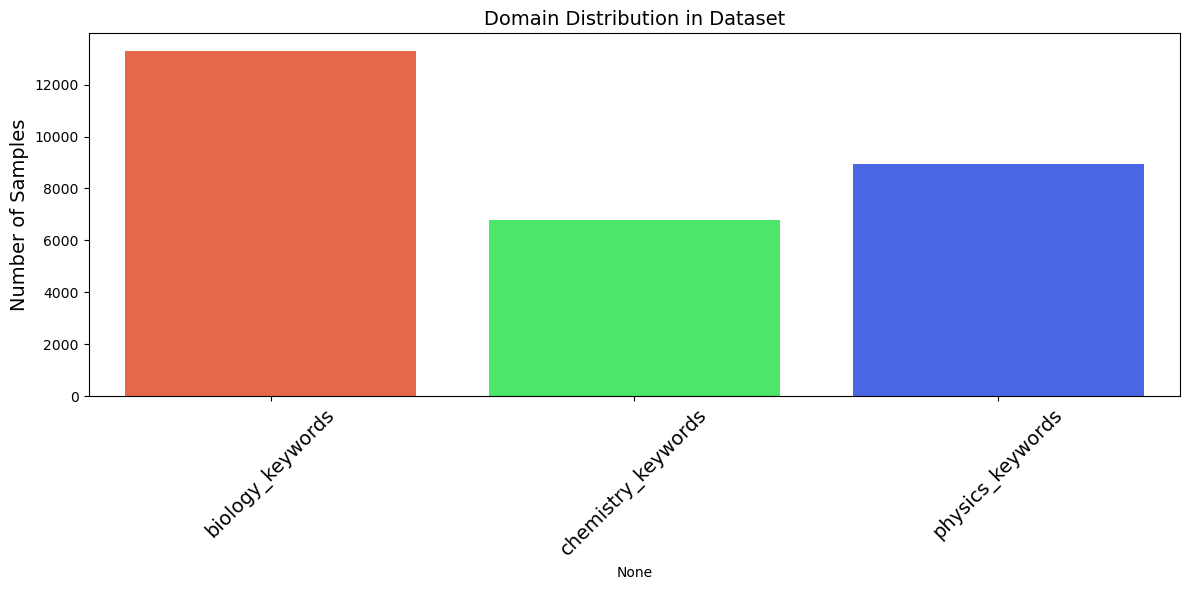

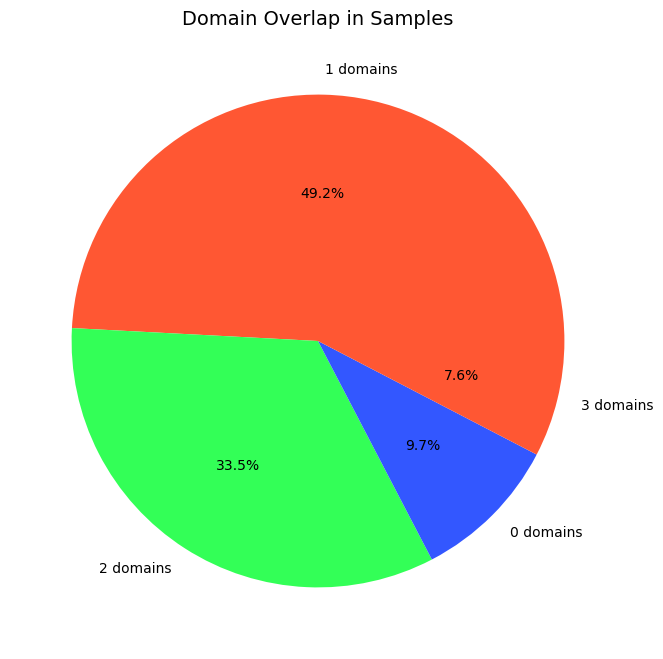

100%|███████████████████████████████████| 20895/20895 [00:15<00:00, 1371.43it/s]


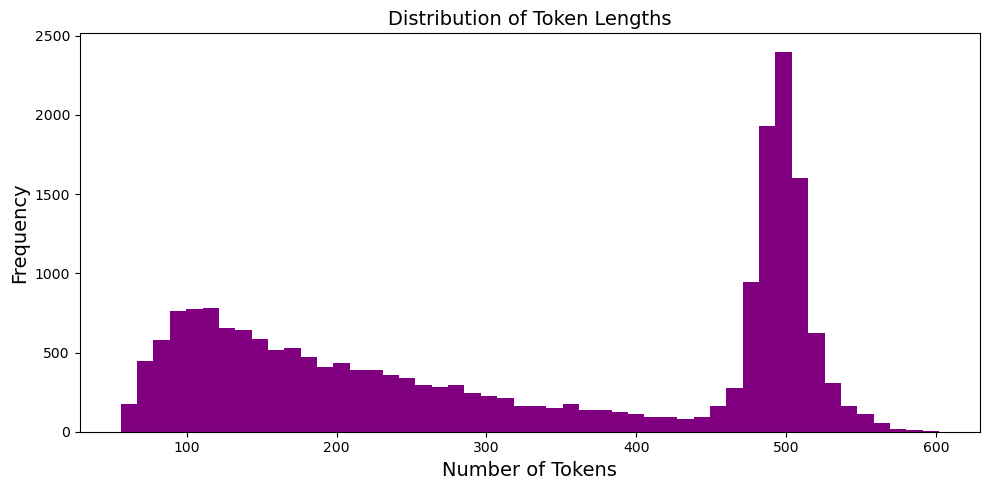


Token Statistics:
Average tokens per sample: 318.28
Vocabulary size: 25766


Analyzing content quality: 100%|██████████| 20895/20895 [06:24<00:00, 54.36it/s]


Detailed Content Analysis:

Basic Metrics:
       avg_sentence_length  unique_words_ratio  technical_terms_count  \
count         20895.000000        20895.000000           20895.000000   
mean             28.007378            0.585697               1.995118   
std              23.551399            0.077949               4.405955   
min               7.375000            0.325527               0.000000   
25%              20.250000            0.532710               0.000000   
50%              24.733333            0.575377               0.000000   
75%              29.692308            0.633028               2.000000   
max             442.000000            0.947368              54.000000   

       biology_terms  chemistry_terms  physics_terms  
count   20895.000000     20895.000000   20895.000000  
mean        5.309643       225.432687       1.410625  
std         6.828439       114.608396       2.535182  
min         0.000000        46.000000       0.000000  
25%         1.000000   

In [8]:
# Cell 8: Execute Analysis
if __name__ == "__main__":
    df = load_dataset()

    # Basic statistics
    stats = compute_basic_stats(df)
    print("\nBasic Statistics:")
    print(stats)
    stats.to_csv("basic_stats.csv", index=False)

    # Domain Analysis
    df = analyze_domains(df)
    plot_domain_distribution(df, colors=['#FF5733', '#33FF57', '#3357FF'], font_size=14)

    # Token Analysis
    token_lengths, vocab_usage = analyze_tokens(df, colors=['#800080'], font_size=14)
    print("\nToken Statistics:")
    print(f"Average tokens per sample: {np.mean(token_lengths):.2f}")
    print(f"Vocabulary size: {len(vocab_usage)}")

    # Content Quality Analysis
    quality_metrics = analyze_content_quality(df)
    quality_metrics.to_csv("quality_metrics_updated.csv", index=False)


Samples per domain:
biology: 13310 samples (63.70%)
chemistry: 6774 samples (32.42%)
physics: 8960 samples (42.88%)

Domain overlap counts:
Samples with 0 domains: 2033 (9.73%)
Samples with 1 domains: 10273 (49.16%)
Samples with 2 domains: 6996 (33.48%)
Samples with 3 domains: 1593 (7.62%)


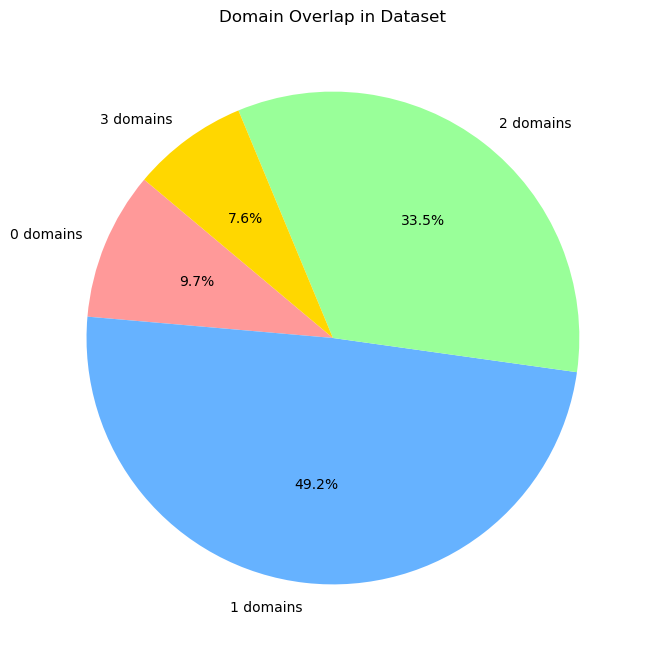

In [9]:
# Cell 9: Detailed Domain Analysis
def print_detailed_domain_stats(df):
    domain_cols = ['biology_keywords', 'chemistry_keywords', 'physics_keywords']
    domain_presence = (df[domain_cols] > 0).sum()

    print("\nSamples per domain:")
    for domain, count in domain_presence.items():
        print(f"{domain.split('_')[0]}: {count} samples ({(count / len(df) * 100):.2f}%)")

    overlap_counts = (df[domain_cols] > 0).sum(axis=1).value_counts().sort_index()

    print("\nDomain overlap counts:")
    for num_domains, count in overlap_counts.items():
        print(f"Samples with {num_domains} domains: {count} ({(count / len(df) * 100):.2f}%)")

    # Pie chart visualization
    plt.figure(figsize=(8, 8))
    plt.pie(overlap_counts, labels=[f'{i} domains' for i in overlap_counts.index], 
            autopct='%1.1f%%', startangle=140, colors=['#FF9999', '#66B2FF', '#99FF99', '#FFD700'])
    plt.title('Domain Overlap in Dataset')
    plt.show()

# Execute the detailed domain analysis
print_detailed_domain_stats(df)

In [10]:
# Cell 10: Load the Multidisciplinary Dataset
df = load_dataset()  # Load the dataset using the function defined in Cell 2

# Print confirmation
print(f"Dataset loaded with {len(df)} samples and the following columns: {list(df.columns)}")

Dataset loaded with 20895 samples and the following columns: ['text', 'source', 'split']


In [11]:
# Cell 11: View the First 5 Rows of the Dataset
print("\nFirst 5 Rows of the Dataset:")
print(df.head())  # Display the first 5 rows


First 5 Rows of the Dataset:
                                                text            source  split
0  jack sarfatti ( born september 14, 1939 ) is a...         wikipedia  train
1  in biochemistry, immunostaining is any use of ...         wikipedia  train
2  question : a lymphocyte is the type of which c...              sciq  train
3  comparative genomics usually involves managing...  lay_summary_plos  train
4  title : effective hamiltonian theory and its a...             arxiv  train


In [12]:
# Cell 12: View Specific Columns of the Dataset
columns_to_view = ['text', 'source']  # Specify the columns you want to view
print(f"\nFirst 5 Rows for Columns {columns_to_view}:")
print(df[columns_to_view].head())  # Display the first 5 rows for the specified columns


First 5 Rows for Columns ['text', 'source']:
                                                text            source
0  jack sarfatti ( born september 14, 1939 ) is a...         wikipedia
1  in biochemistry, immunostaining is any use of ...         wikipedia
2  question : a lymphocyte is the type of which c...              sciq
3  comparative genomics usually involves managing...  lay_summary_plos
4  title : effective hamiltonian theory and its a...             arxiv


In [13]:
# Cell 13: View Specific Columns of the First 15 Rows
columns_to_view = ['text', 'source']  # Specify the columns you want to view
print(f"\nFirst 15 Rows for Columns {columns_to_view}:")
print(df[columns_to_view].head(25))  # Display the first 15 rows for the specified columns


First 15 Rows for Columns ['text', 'source']:
                                                 text             source
0   jack sarfatti ( born september 14, 1939 ) is a...          wikipedia
1   in biochemistry, immunostaining is any use of ...          wikipedia
2   question : a lymphocyte is the type of which c...               sciq
3   comparative genomics usually involves managing...   lay_summary_plos
4   title : effective hamiltonian theory and its a...              arxiv
5   title : microscopic formulation of the s - mat...              arxiv
6   mediator may refer to : a person who engages i...          wikipedia
7   title : the peculiar horizontal branch morphol...              arxiv
8   question : what is the force of attraction bet...               sciq
9   title : effective field theory of gravity : le...              arxiv
10  question : the knee - jerk " motion that peopl...               sciq
11  title : beyond inside - out growth : formation...              arxiv
12  